# Netflix Data Analysis Project

In [15]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [16]:
import pandas as pd
df= pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
df.shape

(8807, 12)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [19]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [20]:
df.duplicated().sum()

np.int64(0)

**STEP-1 LOAD AND INSPECT DATA**

SUMMARY:
1. The Netflix dataset contains 8,807 records and 12 columns related to movies and tv shows available on Netflix
2. The dataset includes information such as title,type,director,cast,country,release year, rating, duration, and description
3. Some columns have missing values, particularly director, cast, country, and date_added.
4. No duplicate records were found in the dataset
5. Most columns contain text data, while the release_year column is numeric.


**STEP-2 DATA CLEANING**

In [21]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


**DATA CLEANING DECISIONS**

1. Missing values in the director column were replaced with "Unknown" because removing these records would result in loss of useful information.

2. Missing values in the cast column were replaced with "Unknown" to retain all records for analysis.

3. Missing values in the country column were replaced with "Unknown" because the country information was unavailable for some titles.

4. Missing values in date_added were filled using the mode (most frequent value) to maintain consistency in the dataset.

5. Missing values in rating were filled using the mode because ratings are important for content analysis.

6. Duplicate records were checked using `df.duplicated().sum()`, and no duplicate rows were found in the dataset.



STEP-3 Exploratory Data Analysis

In [22]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (2).csv


In [23]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

In [24]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


Question 1 observation:The dataset contains both Movies and TV Shows. Movies are more numerous than TV Shows, indicating that Netflix has a larger movie collection.

In [25]:
df['country'].value_counts().head(10)


,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


Question 2 observation:The United States has the highest number of Netflix titles, followed by countries such as India and the United Kingdom. This shows that these countries contribute a large share of Netflix's content.

In [26]:
df.groupby('release_year')['show_id'].count()

,show_id
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


Question 3 observation:The number of titles released increased over the years, with a noticeable rise in recent years. This indicates Netflix's rapid expansion of content.

In [27]:
df.groupby('type')['release_year'].mean()

,release_year
type,
Movie,2013.121514
TV Show,2016.605755


Question 4 Observation:The average release year for Movies and TV Shows is relatively recent, showing that Netflix mainly focuses on modern content.

In [28]:
df['release_year'].describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Question 5 Observation:The statistical summary provides the minimum, maximum, mean, and median release years. It helps understand the overall distribution of release years in the dataset.

Step 4: Data Visualization

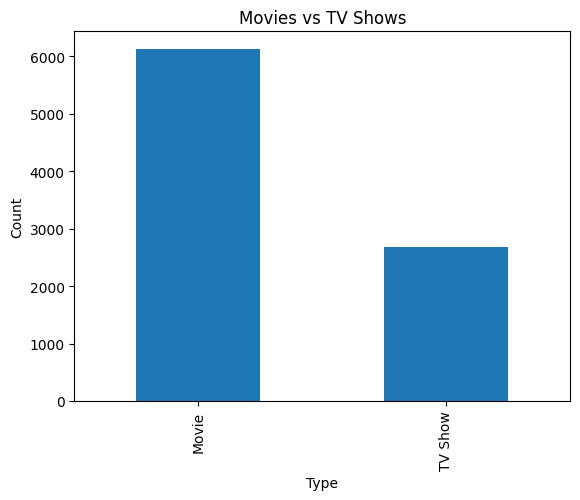

In [29]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

Observation:Movies are available in larger numbers than TV Shows

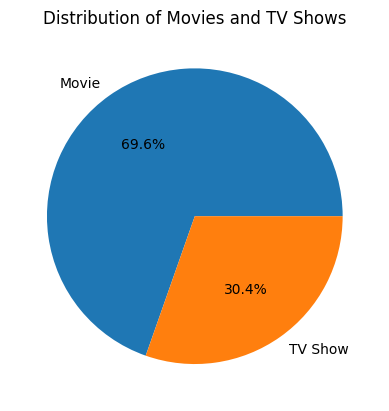

In [30]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Movies and TV Shows')
plt.ylabel('')
plt.show()

Observation:Movies make up the majority of Netflix's content.

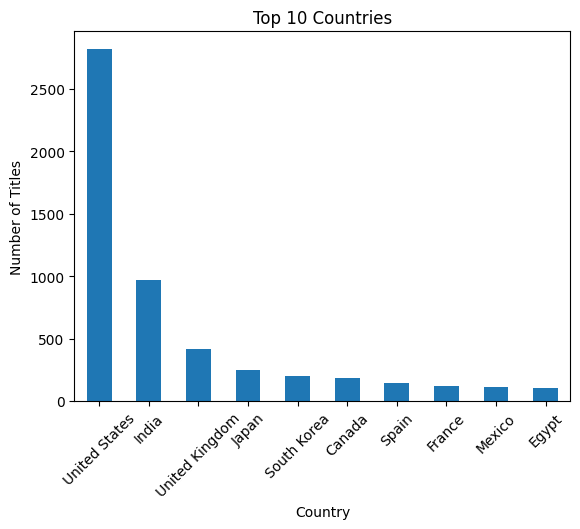

In [31]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

Observation:The United States has the highest number of titles.

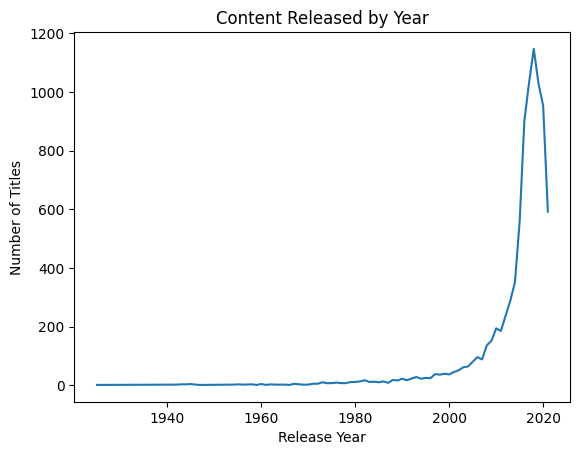

In [32]:
df.groupby('release_year')['show_id'].count().plot(kind='line')
plt.title('Content Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

Observation:Netflix content increased significantly after 2015

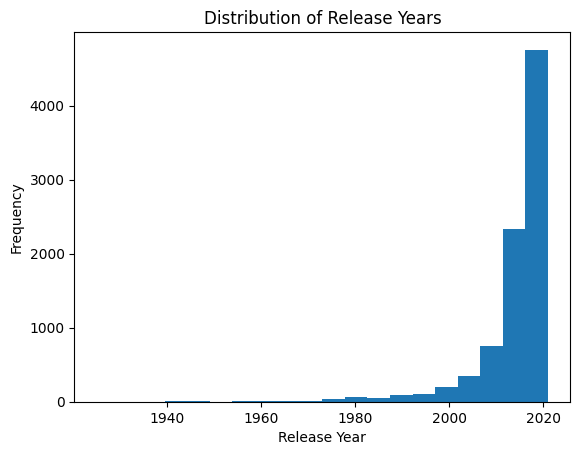

In [33]:
df['release_year'].plot(kind='hist', bins=20)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

Observation:Most content was released in recent years.

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1700/1038105886.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


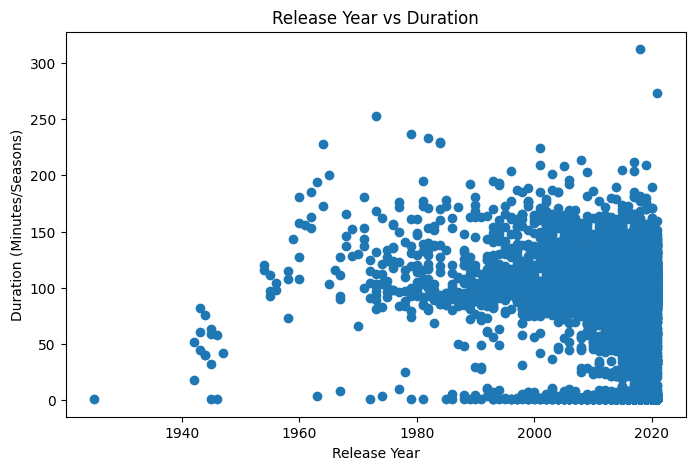

In [34]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(8,5))
plt.scatter(df['release_year'], df['duration_num'])
plt.title('Release Year vs Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes/Seasons)')
plt.show()

Observation:The scatter plot shows the relationship between release year and content duration. Most titles are concentrated in recent years, and there is no strong correlation between release year and duration.

Step 5:Insights Report
1 ) Movies make up a larger portion of Netflix's library than TV Shows.

2 )The United States has the highest number of titles, followed by countries like India and the United Kingdom.

3 )Netflix's content library has grown significantly in recent years, especially after 2015.

4 )Most Netflix titles are relatively recent, showing the platform focuses on modern content.

5 )The majority of titles are concentrated under a few popular content ratings, making them suitable for a wide range of audiences.

Short Note

Finding That Surprised Me the Most

The most surprising finding was the rapid increase in Netflix content after 2015. I also noticed that movies greatly outnumber TV shows in the dataset. This analysis helped me understand how Netflix has expanded its content library over the years.